<a href="https://colab.research.google.com/github/umair594/Data-Scientist-projects/blob/main/Stock%20Market%20Data%20Analysis%20%26%20Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 4-Stock Market Data Analysis & Visualization**

**Objective**

>Perform data analysis and visualization on historical stock market prices to extract trends, volatility, and insights. You’ll learn how to:

Fetch real stock data

>Clean & preprocess time series data

>Compute financial indicators (returns, moving averages)

>Visualize price trends and patterns

>Draw insights from visual analysis

>This project focuses on publicly available historical price data (open, high, low, close, volume).

>The code below uses the yfinance library to fetch historical stock data. You can analyze any stock ticker (e.g., AAPL for Apple, GOOGL for Alphabet).

# **Import Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# **Fetch Historical Stock Data**

You can use Yahoo Finance via yfinance to get historical prices.

In [20]:
# Fetch data for Apple (AAPL) — last 5 years
ticker = 'AAPL'
data = yf.download(ticker, start='2019-01-01', end='2026-03-01')

# Show initial rows
data.head()

/tmp/ipykernel_280/3744159448.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2019-01-01', end='2026-03-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503719,37.724583,36.627397,36.784138,148158800
2019-01-03,33.768082,34.606406,33.722959,34.193179,365248800
2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400
2019-01-07,35.131241,35.344980,34.649145,35.314106,219111200
2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200


**Columns include:**

Open, High, Low, Close, Adj Close, Volume

# **Data Inspection**

Check structure and missing values:

In [21]:
print(data.info())
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1799 entries, 2019-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1799 non-null   float64
 1   (High, AAPL)    1799 non-null   float64
 2   (Low, AAPL)     1799 non-null   float64
 3   (Open, AAPL)    1799 non-null   float64
 4   (Volume, AAPL)  1799 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 84.3 KB
None
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


If missing data exists, you can fill or forward‑fill:

In [22]:
data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_280/2866031220.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


# **Visualize Price Trends**

Closing Price Over Time

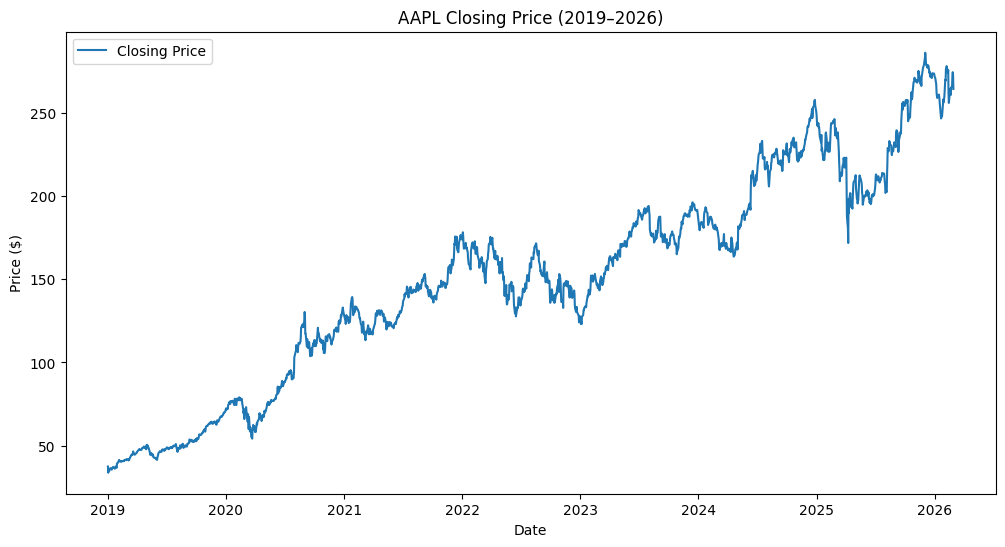

In [23]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label='Closing Price')
plt.title(f'{ticker} Closing Price (2019–2026)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# **Daily Returns & Volatility**

Calculate daily percentage returns:

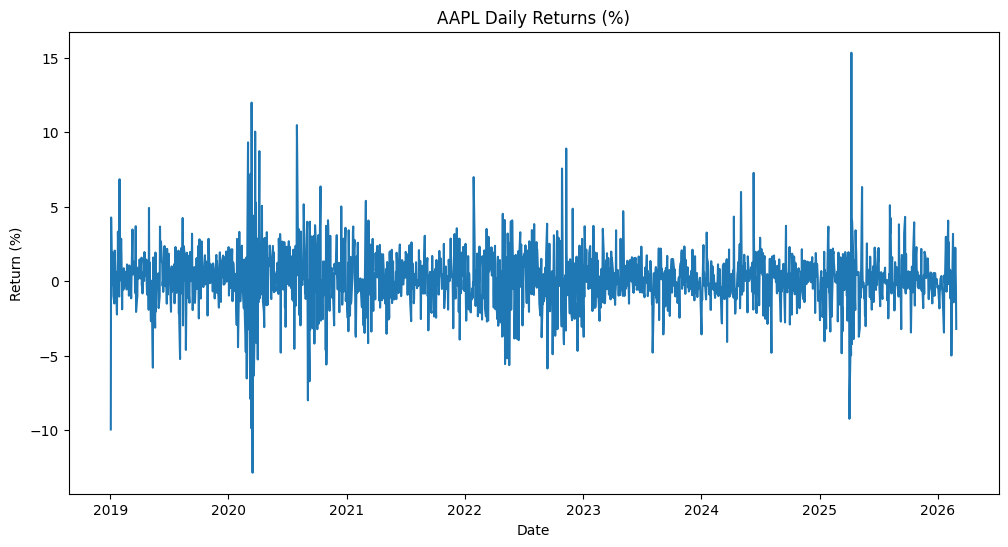

In [24]:
data['Daily Return'] = data['Close'].pct_change() * 100

plt.figure(figsize=(12,6))
plt.plot(data.index, data['Daily Return'], label='Daily Return')
plt.title(f'{ticker} Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.show()

# **Moving Averages (Trend Indicators)**

Compute short‑ and long‑term moving averages:

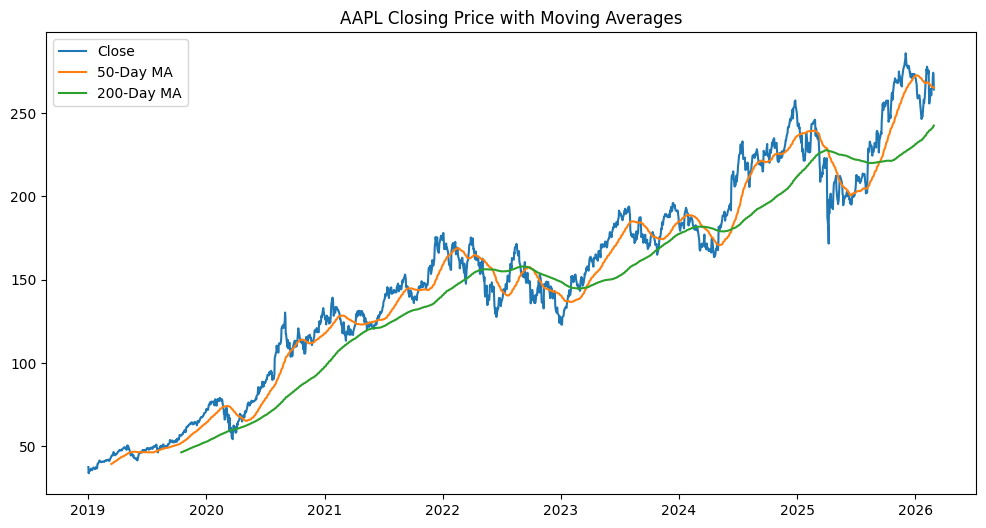

In [25]:
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close')
plt.plot(data['MA50'], label='50‑Day MA')
plt.plot(data['MA200'], label='200‑Day MA')
plt.title(f'{ticker} Closing Price with Moving Averages')
plt.legend()
plt.show()

# **Volume Visualization**

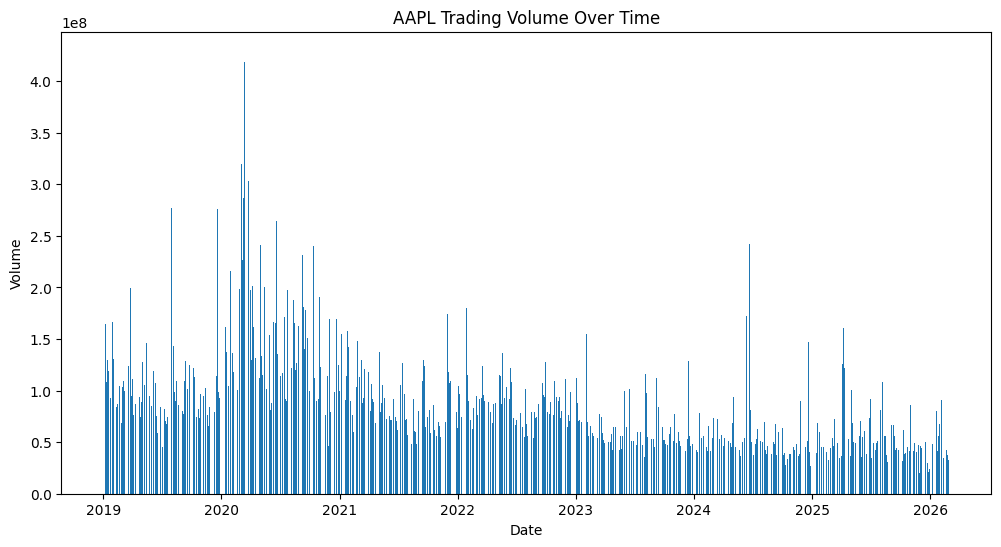

In [27]:
plt.figure(figsize=(12,6))
plt.bar(data.index, data[('Volume', ticker)])
plt.title(f'{ticker} Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

# **Statistical Summary & Correlation**

Summary of key statistical metrics:

In [28]:
print(data[['Close', 'Daily Return']].describe())

Price         Close Daily Return
Ticker         AAPL             
count   1799.000000  1798.000000
mean     150.826061     0.127672
std       62.802270     1.953464
min       33.768082   -12.864691
25%      113.360863    -0.772878
50%      151.633255     0.127926
75%      191.767181     1.133766
max      285.922455    15.328849


Correlation between price and return:

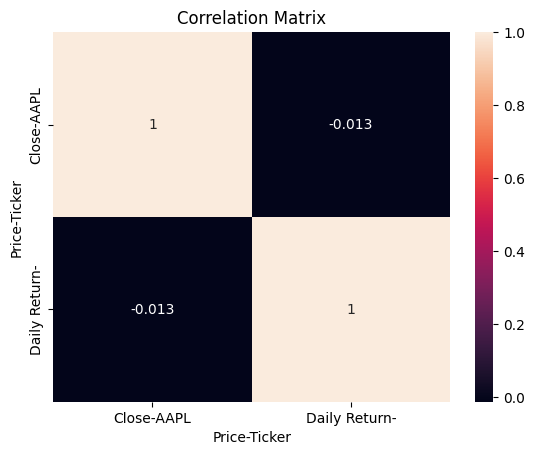

In [29]:
sns.heatmap(data[['Close','Daily Return']].corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

# **Insights You Can Derive**

>Trend Detection: You can visually assess long‑term trends and moving average crossovers (bullish vs bearish phases).

>Volatility: Daily returns show periods of high market fluctuation, indicating risk.

>Volume Patterns: Large spikes can signal significant market interest or events.

# **Save Visualizations and Results**

You can export your figures or save data:

In [30]:
data.to_csv('AAPL_stock_analysis.csv')

# **Optional Add‑Ons**

>To make your project more advanced:

 >Multiple Stocks Comparison — fetch and visualize several tickers side‑by‑side.

 >Technical Indicators — compute RSI, Bollinger Bands, MACD.

 >Interactive Dashboards using Plotly or Streamlit.

 >Time Series Forecasting (e.g., ARIMA or machine learning).

# **Project Summary**

**Deliverables:**

 >Historical stock dataset (CSV)

 >Price trend plots

 >Returns & volatility plots

 >Moving average trendlines

 >Trading volume visualization

 >Correlation analysis

**Skills Demonstrated:**

 >Time series analysis

 >Financial data visualization

 >Data preprocessing

 >Quantitative insights